# Vecka 3 – Kapitel 3: kod

Koduppgifterna 13–16 (12 = avskrift av kapitlets exempel).

## Uppgift 13 – EDA på hr_employee_data.xlsx (ingen ML)

Syftet är en analys en ledningsgrupp kan ta del av.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("../dataset/hr_employee_data.xlsx")

print("Storlek:", df.shape)
print("Saknade värden:", df.isna().sum().sum())
print(df.dtypes)
df.head()

Storlek: (14999, 11)
Saknade värden: 0
Emp_Id                       str
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object


,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [2]:
# Beskrivande statistik
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [3]:
# Hur många har slutat? (left = 1 betyder slutat)
andel = df["left"].mean()
print(f"Andel som slutat: {andel:.1%}")
print(df["left"].value_counts())

Andel som slutat: 23.8%
left
0    11428
1     3571
Name: count, dtype: int64


In [4]:
# Skiljer sig nyckeltal mellan de som stannat (0) och slutat (1)?
kol = ["satisfaction_level", "last_evaluation", "number_project",
       "average_montly_hours", "time_spend_company"]
print(df.groupby("left")[kol].mean().round(2).T)

left                       0       1
satisfaction_level      0.67    0.44
last_evaluation         0.72    0.72
number_project          3.79    3.86
average_montly_hours  199.06  207.42
time_spend_company      3.38    3.88


In [5]:
# Personalomsättning per avdelning och lönenivå
print("Per avdelning:")
print(df.groupby("Department")["left"].mean().sort_values(ascending=False).round(3))
print("\nPer lönenivå:")
print(df.groupby("salary")["left"].mean().round(3))

Per avdelning:
Department
hr             0.291
accounting     0.266
technical      0.256
support        0.249
sales          0.245
marketing      0.237
IT             0.222
product_mng    0.220
RandD          0.154
management     0.144
Name: left, dtype: float64

Per lönenivå:
salary
high      0.066
low       0.297
medium    0.204
Name: left, dtype: float64


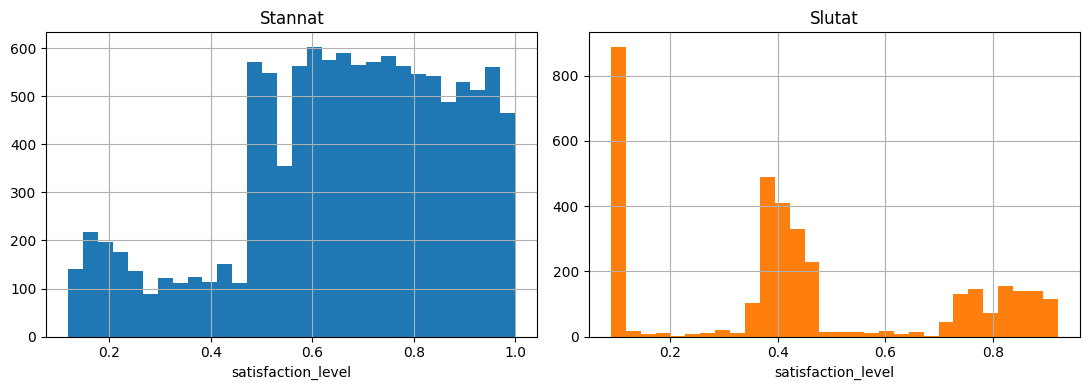

In [6]:
# Enkel visualisering: nöjdhet för de som stannat vs slutat
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[df["left"] == 0]["satisfaction_level"].hist(ax=ax[0], bins=30)
ax[0].set_title("Stannat"); ax[0].set_xlabel("satisfaction_level")
df[df["left"] == 1]["satisfaction_level"].hist(ax=ax[1], bins=30, color="tab:orange")
ax[1].set_title("Slutat"); ax[1].set_xlabel("satisfaction_level")
plt.tight_layout(); plt.show()

## Uppgift 14 – diabetes-datasetet, komplett ML-flöde

In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Beskrivning av datan
data = load_diabetes()
print(data.DESCR[:800])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipo


In [8]:
# Ladda som DataFrame
X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

for namn, m in {"Linjär": LinearRegression(),
                "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1)}.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    print(f"{namn:12} MAE {mean_absolute_error(y_test,p):6.1f}  "
          f"RMSE {mean_squared_error(y_test,p)**0.5:6.1f}  R2 {r2_score(y_test,p):.3f}")

Linjär       MAE   42.8  RMSE   53.9  R2 0.453
RandomForest MAE   44.1  RMSE   54.3  R2 0.443


## Uppgift 15 – car_price_dataset.csv, komplett ML-flöde

Obs: filen är **semikolon-separerad** -> `sep=";"`.

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# a) Komplett flöde, y = Price
df = pd.read_csv("../dataset/car_price_dataset.csv", sep=";")
print("Kolumner:", list(df.columns))
print("Saknade värden:", df.isna().sum().sum())

X = pd.get_dummies(df.drop(columns=["Price"]))   # one-hot på Brand/Model/Fuel_Type/Transmission
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

modell = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
p = modell.predict(X_test)
print(f"RF  MAE {mean_absolute_error(y_test,p):.0f}  "
      f"RMSE {mean_squared_error(y_test,p)**0.5:.0f}  R2 {r2_score(y_test,p):.3f}")

Kolumner: ['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']
Saknade värden: 0


RF  MAE 261  RMSE 335  R2 0.988


### 15 b) Streamlit-app

Spara koden nedan som `app.py` och kör `streamlit run app.py` i terminalen.
Den tränar en modell (eller ladda en sparad med joblib) och låter användaren mata in bildata för att få ett predikterat pris.

```python
import streamlit as st
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

@st.cache_resource
def train():
    df = pd.read_csv("dataset/car_price_dataset.csv", sep=";")
    X = pd.get_dummies(df.drop(columns=["Price"]))
    y = df["Price"]
    modell = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X, y)
    return modell, X.columns, df

modell, kolumner, df = train()

st.title("Bilprisprediktor")
brand = st.selectbox("Brand", sorted(df["Brand"].unique()))
model = st.selectbox("Model", sorted(df["Model"].unique()))
year = st.slider("Year", int(df.Year.min()), int(df.Year.max()), 2015)
engine = st.slider("Engine_Size", float(df.Engine_Size.min()), float(df.Engine_Size.max()), 2.0)
fuel = st.selectbox("Fuel_Type", sorted(df["Fuel_Type"].unique()))
trans = st.selectbox("Transmission", sorted(df["Transmission"].unique()))
mileage = st.number_input("Mileage", 0, 300000, 50000)
doors = st.slider("Doors", int(df.Doors.min()), int(df.Doors.max()), 4)
owners = st.slider("Owner_Count", int(df.Owner_Count.min()), int(df.Owner_Count.max()), 1)

rad = pd.DataFrame([{"Brand":brand,"Model":model,"Year":year,"Engine_Size":engine,
                     "Fuel_Type":fuel,"Transmission":trans,"Mileage":mileage,
                     "Doors":doors,"Owner_Count":owners}])
rad = pd.get_dummies(rad).reindex(columns=kolumner, fill_value=0)
st.metric("Predikterat pris", f"{modell.predict(rad)[0]:,.0f}")
```

### 15 c) Kan det användas i verkligheten?
Ja – samma princip driver värdering av begagnade bilar (Blocket/Kvdbil-liknande tjänster),
försäkringsbolags premiesättning och bilhandlares inköpspriser.


## Uppgift 16 – diamonds.csv, komplett ML-flöde

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../dataset/diamonds.csv").drop(columns=["Unnamed: 0"])  # bara radnummer
print("Storlek:", df.shape, " Saknade:", df.isna().sum().sum())

X = pd.get_dummies(df.drop(columns=["price"]))   # one-hot på cut/color/clarity
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

modell = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
p = modell.predict(X_test)
print(f"RF  MAE {mean_absolute_error(y_test,p):.0f}  "
      f"RMSE {mean_squared_error(y_test,p)**0.5:.0f}  R2 {r2_score(y_test,p):.3f}")

Storlek: (53940, 10)  Saknade: 0


RF  MAE 270  RMSE 550  R2 0.981


In [11]:
# Viktigaste variablerna enligt modellen
import pandas as pd
vikter = pd.Series(modell.feature_importances_, index=X.columns).sort_values(ascending=False)
print(vikter.head(6).round(3).to_string())

carat          0.613
y              0.273
clarity_SI2    0.019
clarity_I1     0.015
clarity_SI1    0.014
color_J        0.010
